In [1]:
# Setup
import os, sys, torch
from argparse import Namespace

repo_root = "/scratch/jq2uw/MME/instruct_vlm_edit"
os.chdir(repo_root)
sys.path.append(repo_root) if repo_root not in sys.path else None

from revlm.config_utils import configure_args
from revlm import VQAModel, VQADataset
from revlm.editors.auto_q import AutoLayer, ModularityCore


In [2]:
# Load model & dataset
args = Namespace(config="revlm/config/config.yaml", editor="ike_chain", model_name="qwen3_4b",
                 dataset_name="aokvqa", task="mc", batch_size=1, split="all",
                 rationale=False, cot=False, subsample=100, overwrite=False)
args.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
config = configure_args(args, config_path=args.config)

model = VQAModel(config)
dataset = VQADataset(config)
print(f"Model: {config.model.name}, Dataset: {len(dataset)} samples")


Task evaluation metrics will be saved to results/te/ike_chain/Qwen3-VL-4B-Instruct/aokvqa
Edit evaluation metrics will be saved to results/ee/ike_chain/Qwen3-VL-4B-Instruct/aokvqa
Predictions will be saved to results/pred/Qwen3-VL-4B-Instruct/aokvqa
Post-edit predictions will be saved to results/pred_postedit/ike_chain/Qwen3-VL-4B-Instruct/aokvqa
Unified filename to save: mc_all_sub100.json
Model: Qwen/Qwen3-VL-4B-Instruct, Dataset: 18195 samples


In [3]:
# Print target matrices to understand Vision Q vs Language Q
# Vision Q: cluster by image (same image -> same cluster)
# Language Q: cluster by text (same text -> same cluster)
ModularityCore.print_targets(n=3)


=== Target matrices for n=3 samples ===

[Vision Q Target (cluster by image)]
           <i1,t1>  <i1,t2>  <i1,t3>  <i2,t1>  <i2,t2>  <i2,t3>  <i3,t1>  <i3,t2>  <i3,t3>
 <i1,t1>         1        1        1        0        0        0        0        0        0
 <i1,t2>         1        1        1        0        0        0        0        0        0
 <i1,t3>         1        1        1        0        0        0        0        0        0
 <i2,t1>         0        0        0        1        1        1        0        0        0
 <i2,t2>         0        0        0        1        1        1        0        0        0
 <i2,t3>         0        0        0        1        1        1        0        0        0
 <i3,t1>         0        0        0        0        0        0        1        1        1
 <i3,t2>         0        0        0        0        0        0        1        1        1
 <i3,t3>         0        0        0        0        0        0        1        1        1

[Language Q

In [4]:
# Initialize AutoLayer and get candidate layers
# n_samples: number of samples for Q computation
# n_aug: number of augmentations per sample for pure vision/language Q
auto = AutoLayer(config, model, n_samples=20, n_aug=10)
# , edge_filter="disparity", edge_filter_kwargs={"alpha": 0.005})
layers = auto.get_candidate_layers()


[AutoLayer] 92 layers (vision: 48, merger: 8, language: 36)


In [5]:
# Find best layers - computes 5 scores per layer:
# - vision_Q: entangled <img,text> n×n pairs, cluster by image
# - language_Q: entangled <img,text> n×n pairs, cluster by text  
# - harmonic: harmonic mean of vision_Q and language_Q
# - pure_vision_Q: <image, ""> with image augs, cluster by sample
# - pure_language_Q: <blank, text> with text augs, cluster by sample
best, scores = auto.find_best(dataset, layers)


[AutoLayer] 20 samples, 92 layers
            Entangled: 20×20 = 400 pairs
            Pure Vision: 20 × (1 + 10) = 220
            Pure Language: 20 × (1 + 10) = 220
            Bi-modality: 20 × (1 + 10) = 220
            Total: 1060 forwards


encoding:  59%|█████████████████████████▏                 | 621/1060 [00:58<00:46,  9.39it/s]

[Augmenter] Loading Qwen/Qwen2.5-0.5B-Instruct...


encoding: 100%|██████████████████████████████████████████| 1060/1060 [07:36<00:00,  2.32it/s]


[SBERT] language_Q baseline = 0.0806


...

  language_model.layers.33.mlp.gate_proj.weight: vis=0.083, lang=-0.005, H=0.000, p_vis=0.034, p_lang=0.013, bi=0.038


scoring:  99%|██████████████████████████████████████████████▍| 91/92 [00:10<00:00,  9.12it/s]

  language_model.layers.34.mlp.gate_proj.weight: vis=0.080, lang=-0.004, H=0.000, p_vis=0.034, p_lang=0.010, bi=0.037


scoring: 100%|███████████████████████████████████████████████| 92/92 [00:10<00:00,  8.86it/s]

  language_model.layers.35.mlp.gate_proj.weight: vis=0.084, lang=-0.004, H=0.000, p_vis=0.032, p_lang=0.009, bi=0.033

[Shift] global_min=-0.0107, global_min_pure=0.0017

Best layers per metric:
  vision_Q:
    overall         → model.visual.blocks.21.mlp.linear_fc1.weight (0.162)
    vision_layer    → model.visual.blocks.21.mlp.linear_fc1.weight (0.162)
    merger_layer    → model.visual.merger.linear_fc2.weight (0.132)
    language_layer  → model.language_model.layers.0.mlp.gate_proj.weight (0.093)
  language_Q:
    overall         → model.language_model.layers.23.mlp.gate_proj.weight (-0.001)
    vision_layer    → model.visual.blocks.23.mlp.linear_fc2.weight (-0.004)
    merger_layer    → model.visual.deepstack_merger_list.0.linear_fc2.weight (-0.005)
    language_layer  → model.language_model.layers.23.mlp.gate_proj.weight (-0.001)
  harmonic:
    overall         → model.language_model.layers.20.mlp.gate_proj.weight (0.000)
    vision_layer    → model.visual.blocks.23.mlp.linear_fc

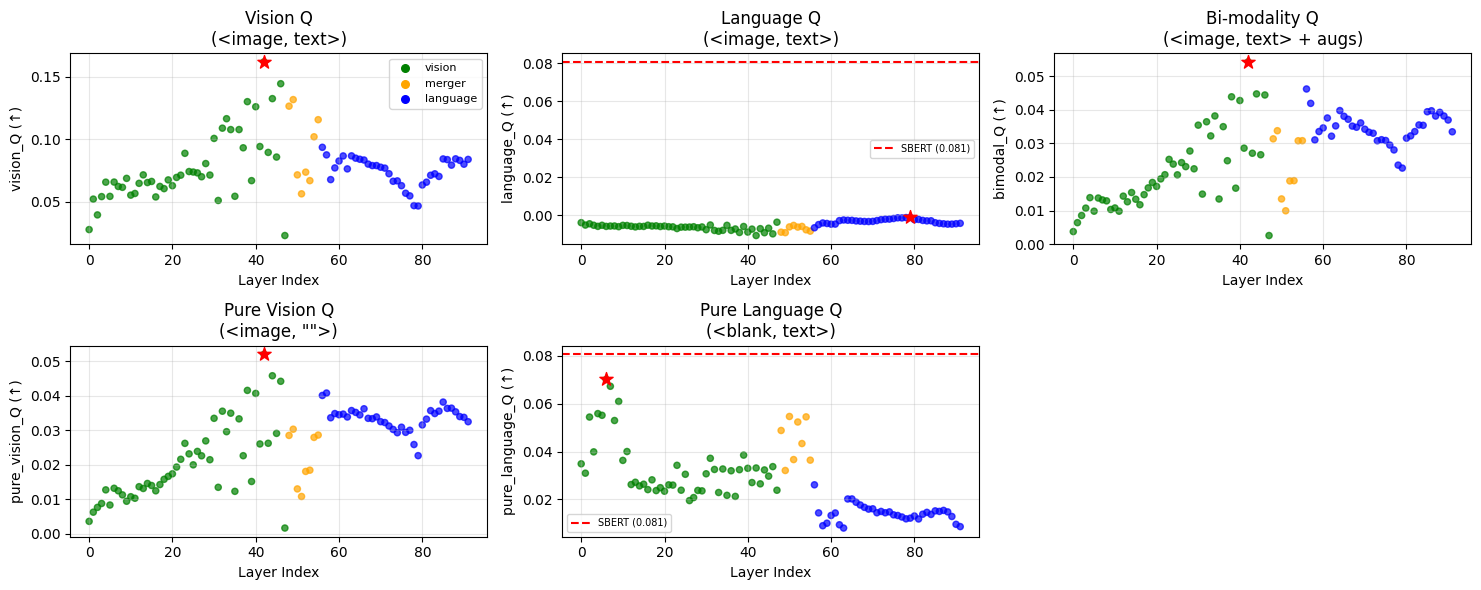

In [6]:
# Plot all 5 Q scores vs layer index
# Top row: Entangled (Vision Q, Language Q, Harmonic)
# Bottom row: Pure (Pure Vision Q, Pure Language Q)
# Colors: Green = vision layers, Orange = merger layers, Blue = language layers
# Red star = best layer for each metric
auto.plot(scores)


In [7]:
# Print best layers summary
print("Best layers:")
for metric_name, bests in best.items():
    print(f"\n  {metric_name}:")
    for group, layer in bests.items():
        if layer and layer in scores:
            s = scores[layer]
            bimodal = s.get('bimodal_Q', 0)
            print(f"    {group:15} → ...{layer[-45:]}")
            print(f"      vis={s['vision_Q']:.3f}, lang={s['language_Q']:.3f}, bi={bimodal:.3f}")

Best layers:

  vision_Q:
    overall         → ...model.visual.blocks.21.mlp.linear_fc1.weight
      vis=0.162, lang=-0.011, bi=0.054
    vision_layer    → ...model.visual.blocks.21.mlp.linear_fc1.weight
      vis=0.162, lang=-0.011, bi=0.054
    merger_layer    → ...model.visual.merger.linear_fc2.weight
      vis=0.132, lang=-0.009, bi=0.034
    language_layer  → ....language_model.layers.0.mlp.gate_proj.weight
      vis=0.093, lang=-0.007, bi=0.046

  language_Q:
    overall         → ...language_model.layers.23.mlp.gate_proj.weight
      vis=0.047, lang=-0.001, bi=0.023
    vision_layer    → ...model.visual.blocks.23.mlp.linear_fc2.weight
      vis=0.023, lang=-0.004, bi=0.003
    merger_layer    → ...ual.deepstack_merger_list.0.linear_fc2.weight
      vis=0.056, lang=-0.005, bi=0.010
    language_layer  → ...language_model.layers.23.mlp.gate_proj.weight
      vis=0.047, lang=-0.001, bi=0.023

  harmonic:
    overall         → ...language_model.layers.20.mlp.gate_proj.weight
      

In [8]:
# Cleanup hooks when done
auto.cleanup()


# Load Saved Results (After Running Jobs)

After running `jobs/auto_layer/run.sh`, use the cells below to load aggregated results with error bars.


In [9]:
# Setup
import os, sys, torch
from argparse import Namespace

repo_root = "/scratch/jq2uw/MME/instruct_vlm_edit"
os.chdir(repo_root)
sys.path.append(repo_root) if repo_root not in sys.path else None

from revlm.config_utils import configure_args
from revlm import VQAModel, VQADataset
from revlm.editors.auto_q import AutoLayer, ModularityCore


In [10]:
# Load aggregated results from saved runs (with error bars)
# Change model_name to match your saved results
model_name = "blip"  # Options: "blip", "llava", "qwen3", "qwen3_4b"

args = Namespace(config="revlm/config/config.yaml", editor="ike_chain", model_name=model_name,
                 dataset_name="aokvqa", task="mc", batch_size=1, split="all",
                 rationale=False, cot=False, subsample=100, overwrite=False)
args.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
config = configure_args(args, config_path=args.config)

# Create AutoLayer just for loading (no model needed)
auto_loader = AutoLayer.__new__(AutoLayer)
auto_loader.config = config
auto_loader.device = args.device

# Load aggregated results
agg_scores = auto_loader.load_results_k(out_dir="results/auto_layer")
if agg_scores:
    best = auto_loader.get_best_from_agg(agg_scores)


Task evaluation metrics will be saved to results/te/ike_chain/instructblip-vicuna-7b/aokvqa
Edit evaluation metrics will be saved to results/ee/ike_chain/instructblip-vicuna-7b/aokvqa
Predictions will be saved to results/pred/instructblip-vicuna-7b/aokvqa
Post-edit predictions will be saved to results/pred_postedit/ike_chain/instructblip-vicuna-7b/aokvqa
Unified filename to save: mc_all_sub100.json
[AutoLayer] Loading 3 runs...
[AutoLayer] Aggregated 3 runs, 111 layers
Best layers (from mean):
  vision_Q:
    overall         → vision_model.encoder.layers.36.mlp.fc1.weight (0.033±0.004)
    vision_layer    → vision_model.encoder.layers.36.mlp.fc1.weight (0.033±0.004)
    merger_layer    → language_projection.weight (0.007±0.001)
    language_layer  → language_model.model.layers.23.mlp.gate_proj.weight (0.008±0.000)
  language_Q:
    overall         → language_model.model.layers.11.mlp.gate_proj.weight (0.006±0.000)
    vision_layer    → vision_model.encoder.layers.0.mlp.fc1.weight (-0.0

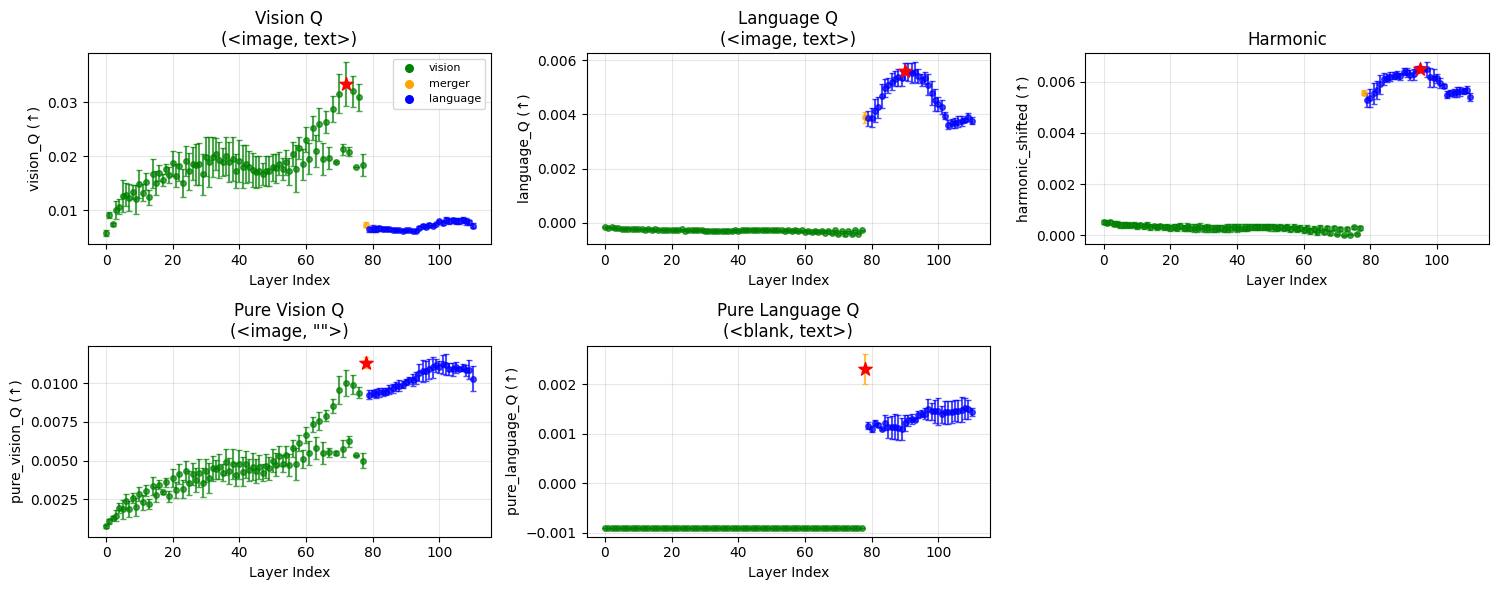

In [11]:
# Plot aggregated results with error bars
# Requires loading model for layer classification (or use auto from earlier cells)
if agg_scores:
    # If you have auto from earlier cells, use it:
    # auto.plot(agg_scores)
    
    # Or create minimal AutoLayer for plotting
    auto_loader._classify_layers = lambda layers: AutoLayer._classify_layers(auto_loader, layers)
    auto_loader._is_aggregated = lambda scores: AutoLayer._is_aggregated(auto_loader, scores)
    auto_loader.plot = lambda scores, **kwargs: AutoLayer.plot(auto_loader, scores, **kwargs)
    
    auto_loader.plot(agg_scores, figsize=(15, 6))
else:
    print("No saved results found. Run jobs/auto_layer/run.sh first.")
